# 04 - Project Summary

A recruiter/stakeholder-facing summary of the customer-churn-predictor project: the business problem, key EDA findings, model comparison, top churn drivers, business recommendations, and next steps. Pulls its numbers live from the PostgreSQL database and the `data/processed/` artifacts generated by earlier notebooks/scripts.

In [1]:
import os
import pandas as pd
from IPython.display import Image, display
from dotenv import load_dotenv
load_dotenv('../.env')
import sys; sys.path.insert(0, '..')
os.chdir('..')  # match repo-root-relative paths used by src/models scripts
from src.utils.db import get_engine

pd.set_option('display.max_columns', None)
engine = get_engine()

## Section 1 - Project Overview & Business Problem

**Overview:** An end-to-end machine learning system that predicts telecom customer churn using the Telco Customer Churn dataset. The project covers the full ML lifecycle: data ingestion, feature engineering, model training, evaluation, experiment tracking (MLflow), serving via a REST API (FastAPI), and an interactive dashboard (Streamlit) — with GPT-powered natural-language explanations for each at-risk customer.

**Business problem:** Retaining existing customers is significantly cheaper than acquiring new ones. This project helps customer-success and marketing teams identify which customers are likely to churn in the next billing cycle so they can take proactive action (discounts, outreach, plan changes) before the customer leaves.

## Section 2 - Data Summary & EDA Key Findings

In [2]:
raw = pd.read_sql('SELECT * FROM raw_customers', engine)
print(f"Rows: {len(raw):,}   Columns: {raw.shape[1]}")
print(f"Overall churn rate: {(raw['churn'] == 'Yes').mean():.1%}")

Rows: 7,043   Columns: 22
Overall churn rate: 26.0%


In [3]:
contract_churn = raw.groupby('contract')['churn'].apply(lambda s: (s == 'Yes').mean() * 100).round(1)
contract_churn.sort_values(ascending=False).to_frame('churn_rate_pct')

,churn_rate_pct
contract,
Month-to-month,47.5
One year,0.0
Two year,0.0


In [4]:
tenure_bins = pd.cut(raw['tenure'], bins=[0, 12, 24, 48, 1000],
                     labels=['0-12mo', '12-24mo', '24-48mo', '48mo+'], include_lowest=True)
tenure_churn = raw.groupby(tenure_bins, observed=True)['churn'].apply(lambda s: (s == 'Yes').mean() * 100).round(1)
tenure_churn.to_frame('churn_rate_pct')

,churn_rate_pct
tenure,
0-12mo,73.7
12-24mo,14.4
24-48mo,0.0
48mo+,0.0


In [5]:
payment_churn = raw.groupby('payment_method')['churn'].apply(lambda s: (s == 'Yes').mean() * 100).round(1)
payment_churn.sort_values(ascending=False).to_frame('churn_rate_pct')

,churn_rate_pct
payment_method,
Electronic check,33.7
Credit card (automatic),22.7
Bank transfer (automatic),22.1
Mailed check,21.5


**Key EDA findings** (see `notebooks/01_eda.ipynb` for the full analysis):
- Month-to-month contracts churn far more than one/two-year contracts.
- Customers with tenure under 12 months are the highest-risk group.
- Electronic check payment correlates with the highest churn rate of all payment methods.
- Fiber optic internet and lack of online security/tech support are both associated with elevated churn.

## Section 3 - Model Comparison & Best Model

In [6]:
leaderboard = pd.read_csv('data/processed/final_model_leaderboard.csv').sort_values('AUC', ascending=False)
leaderboard

,Model,Accuracy,AUC,F1,Precision,Recall
0,XGBoost (tuned),0.899929,0.962388,0.812250,0.792208,0.833333
1,Ensemble,0.897800,0.961079,0.813953,0.772059,0.860656
2,Logistic Regression,0.894961,0.960284,0.799458,0.793011,0.806011
3,LightGBM,0.877928,0.959966,0.795238,0.704641,0.912568
4,Random Forest (tuned),0.899929,0.959794,0.810738,0.796834,0.825137
5,Decision Tree,0.901348,0.957688,0.815405,0.793282,0.838798


In [7]:
active = pd.read_sql('SELECT model_name, model_version, accuracy, auc_score, f1_score, trained_at \
                       FROM model_registry WHERE is_active = TRUE', engine)
print('Active production model:')
active

Active production model:


,model_name,model_version,accuracy,auc_score,f1_score,trained_at
0,xgboost_tuned,v2,0.899929,0.962388,0.81225,2026-07-03 14:14:44.380950


**Best model:** `xgboost_tuned` (GridSearchCV-tuned XGBoost) is the current production model, selected for the best AUC among all 6 models trained (baseline Logistic Regression / Decision Tree / Random Forest / XGBoost, plus tuned Random Forest & XGBoost, LightGBM, and a soft-voting Ensemble). It is registered as `Production` in the MLflow Model Registry and marked `is_active=True` in the `model_registry` Postgres table.

## Section 4 - Key Churn Drivers (SHAP Top Features)

In [8]:
importance = pd.read_csv('data/processed/rf_feature_importance.csv').sort_values('importance', ascending=False)
importance.head(10)

,feature,importance
0,charge_per_month,0.369414
1,tenure_group_New Customer,0.237918
2,contract_risk_score,0.178523
3,tenure_group_Growing Customer,0.077329
4,services_count,0.052389
5,payment_risk_score,0.037816
6,tenure_group_Established Customer,0.036380
7,tenure_group_Loyal Customer,0.010233


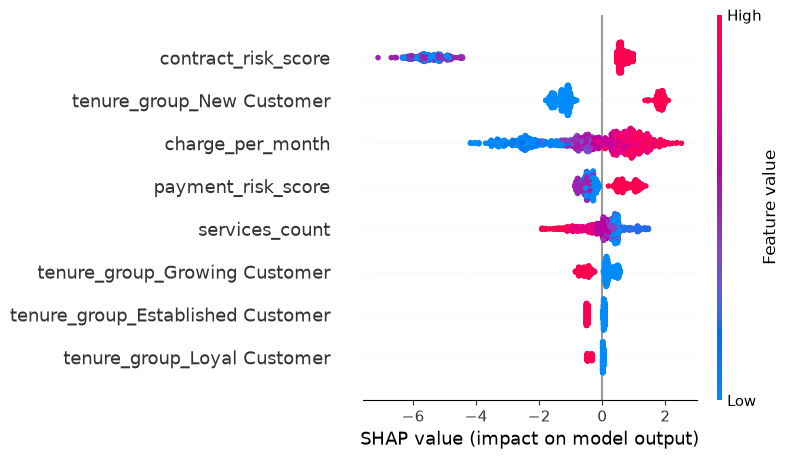

In [9]:
display(Image(filename='data/processed/shap_plots/shap_summary_beeswarm.png'))

**Top churn drivers:** `charge_per_month`, `tenure_group_New Customer`, and `contract_risk_score` dominate the model's feature importance — together they explain the majority of the model's predictive signal. This matches the EDA findings above: new, high-paying, month-to-month customers are consistently the highest churn risk.

## Section 5 - Business Recommendations

In [10]:
targets = pd.read_csv('data/processed/retention_targets.csv')
tier_summary = targets.groupby('priority_tier').agg(
    customers=('customer_id', 'count'),
    avg_churn_probability=('churn_probability', 'mean'),
    monthly_revenue_at_risk=('monthly_charges', 'sum'),
).round(2)
tier_summary

,customers,avg_churn_probability,monthly_revenue_at_risk
priority_tier,,,
Tier 1,1006,0.92,86864.65
Tier 2,266,0.89,15665.73
Tier 3,69,0.80,1674.72


1. **Target Tier 1 customers first** — highest churn probability *and* highest monthly value. Prioritize personal outreach (phone call + discount offer) over automated channels.
2. **Incentivize longer contracts** — since month-to-month is the single biggest churn driver, offer a meaningful discount or perk for customers who switch to a 1- or 2-year contract.
3. **Intervene early in the customer lifecycle** — tenure under 12 months is consistently high-risk; build a structured onboarding/check-in program for new customers.
4. **Push autopay adoption** — electronic check has the highest churn correlation of any payment method; incentivize switching to automatic bank transfer or credit card payment.
5. **Bundle protective services** — customers without online security or tech support churn more; offering a free trial of these add-ons increases switching cost and perceived value.

## Section 6 - Next Steps & Future Work
- Real-time streaming predictions with Kafka
- A/B testing framework for retention campaigns
- Email notification system for high risk alerts
- Integration with CRM systems (Salesforce)
- Deep learning model (Neural Network) comparison
- Automated retraining pipeline with Airflow